In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
import linearmodels as lm 
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import sys
import os

sys.path.append('../Scripts') 

#sys.path.append('C:/Users/admin/Documents/1WBS/3Data_Cln_Stry/eniac_cleaning/Scripts')

import Elasticities as el


## Functions

In [2]:
#Function to group data
def group_nlog (df: pd.DataFrame, group_cols: list):
    grouped_df = resample_nlog(df.groupby(group_cols))
    return grouped_df

#Resamples dataframe for frequency and calculates aggregates needed for calculating elasticities
def resample_nlog(df, freq='d'):
    resample_df = (df.resample(freq, on='date')
                     .agg(sales=('product_quantity', 'sum'), 
                          price=('unit_price', 'mean'), 
                          discount=('discount', 'mean'))
                    #.reset_index()
                    )
    resample_df['log_sales'] = np.log(resample_df['sales'] + 1) 
    resample_df['log_discount'] = np.log(resample_df['discount'] + 1)
    return(resample_df)

#Conducts a fixed effects regression
def fixed_reg(df):
    model = lm.PanelOLS.from_formula(
    'log_sales ~ log_discount + EntityEffects', 
    data=df
    )
    results = model.fit()
    return results

#Formats a scatter plot showing the relationship between discounts and sales
def plot_nformat(df):
     slope, intercept, r_value, p_value, std_err = stats.linregress(
     df['log_discount'], df['log_sales']
     )

     sns.set_style("whitegrid")
     plt.figure(figsize=(10, 6))

     g = sns.lmplot(
     data=df,
     x='log_discount', 
     y='log_sales',
     height=6,
     aspect=1.3,
     scatter_kws={'alpha': 0.6, 's': 60, 'color': 'steelblue'},
     line_kws={'color': 'red', 'linewidth': 2},
     ci=95
     )

     plt.title(f'Log Discount vs Log Sales\n'
               f'y = {intercept:.3f} + {slope:.3f}x (R²={r_value**2:.3f})')
     plt.tight_layout()
     plt.show()

def create_lags (df, nlags, col_name):
    for n in range(1, nlags + 1):
        df[col_name + '_lag' + str(n)] = df[col_name].shift(n)
    return(df.dropna())



### Read data

In [3]:
clean_df = pd.read_csv('C:/Users/admin/Documents/1WBS/3Data_Cln_Stry/eniac_cleaning/data/processed/clean_df.csv',
                      parse_dates=['date', 'created_date'])

daily_df = resample_nlog(clean_df)
weekly_df = resample_nlog(clean_df, 'W')

## Overall regressions

In [4]:
daily_df_lags = create_lags(daily_df, 5, 'log_discount')

model = LinearRegression().fit(daily_df_lags[['log_discount', 'log_discount_lag1']], daily_df_lags['log_sales'])
print(model.coef_)

X = daily_df_lags[['log_discount', 'log_discount_lag1', 'log_discount_lag2', 'log_discount_lag3', 'log_discount_lag4', 'log_discount_lag5']]
y = daily_df_lags['log_sales']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# Print comprehensive results
print(model.summary())

[0.38039859 0.00365523]
                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     3.010
Date:                Mon, 24 Nov 2025   Prob (F-statistic):            0.00683
Time:                        17:27:20   Log-Likelihood:                -333.24
No. Observations:                 433   AIC:                             680.5
Df Residuals:                     426   BIC:                             709.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const         

## Plots

<Figure size 1000x600 with 0 Axes>

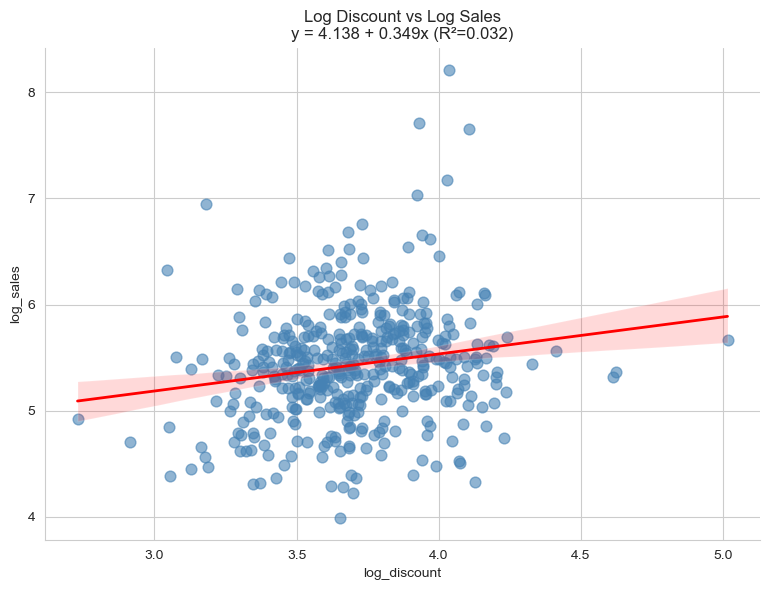

<Figure size 1000x600 with 0 Axes>

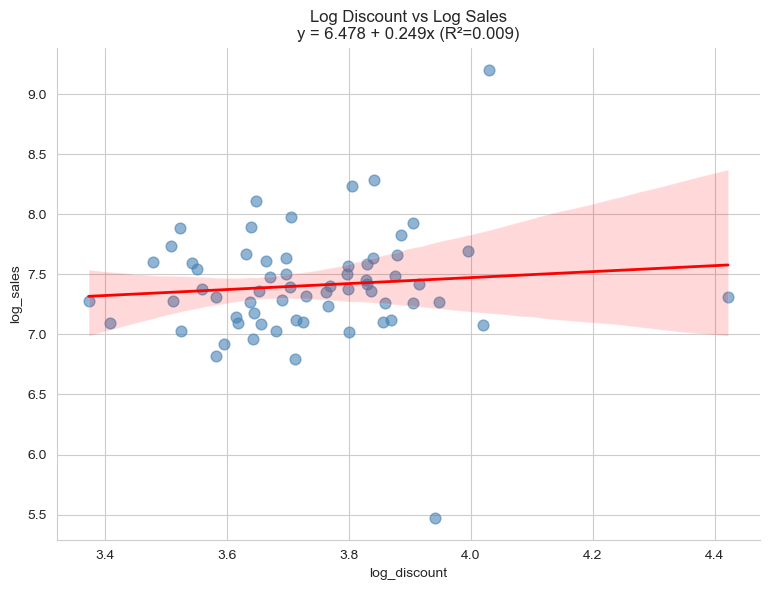

In [5]:
plot_nformat(daily_df)
plot_nformat(weekly_df)

## Regressions grouped by categories

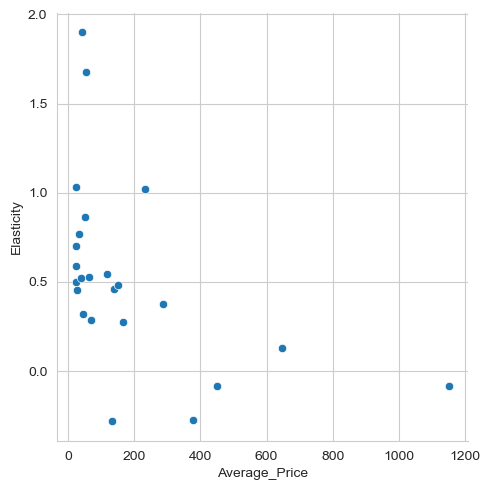

In [14]:
brand_elasticities = el.group_elasticities(clean_df, 'long', 'W')

el._group_nlog(clean_df, 'long', 'W')#.price.sum()
brand_elasticities

sns.relplot(data=brand_elasticities[brand_elasticities.Sales>1000],
            x = 'Average_Price',
            y = 'Elasticity')

#el.group_elasticities?

### Grouped by price category

In [7]:
grouped_p_category = group_nlog(clean_df, ['price_category'])
print(fixed_reg(grouped_p_category))


                          PanelOLS Estimation Summary                           
Dep. Variable:              log_sales   R-squared:                        0.0099
Estimator:                   PanelOLS   R-squared (Between):              0.3299
No. Observations:                2186   R-squared (Within):               0.0099
Date:                Mon, Nov 24 2025   R-squared (Overall):              0.3203
Time:                        17:27:23   Log-likelihood                   -2063.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      21.748
Entities:                           5   P-value                           0.0000
Avg Obs:                       437.20   Distribution:                  F(1,2180)
Min Obs:                       434.00                                           
Max Obs:                       438.00   F-statistic (robust):             21.748
                            

c:\Users\admin\anaconda3\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


In [8]:
model?
print(model.params.log_discount)
print(model.pvalues.log_discount)

0.352732154629074
0.0007533952424831877


Type:            RegressionResultsWrapper
String form:     <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x000002A2B60AE900>
File:            c:\users\admin\anaconda3\lib\site-packages\statsmodels\regression\linear_model.py
Docstring:      
Results class for for an OLS model.

Parameters
----------
model : RegressionModel
    The regression model instance.
params : ndarray
    The estimated parameters.
normalized_cov_params : ndarray
    The normalized covariance parameters.
scale : float
    The estimated scale of the residuals.
cov_type : str
    The covariance estimator used in the results.
cov_kwds : dict
    Additional keywords used in the covariance specification.
use_t : bool
    Flag indicating to use the Student's t in inference.
**kwargs
    Additional keyword arguments used to initialize the results.

See Also
--------
RegressionResults
    Results store for WLS and GLW models.

Notes
-----
Most of the methods and attributes are inherited from Regre

In [9]:
df = grouped_p_category.reset_index()
group_col = 'price_category'
elasticities_df = pd.DataFrame(columns=[group_col, 'Elasticity', 'P_value'])

def elasticity_calc(df, group_col):
    elasticities_df = pd.DataFrame(columns=[group_col, 'Elasticity', 'P_value'])
    for i in df[group_col].unique():
        subset = df[df[group_col] == i].dropna()
        X = subset[['log_discount']]
        y = subset['log_sales']
        X = sm.add_constant(X)
        model = sm.OLS(y, X).fit()
        #print(i)
        #print(model.summary())
        elasticities_df.loc[len(elasticities_df)] = [i, model.params.log_discount, model.pvalues.log_discount]
    return elasticities_df

### Grouped by brand and price category

In [10]:
grouped_df = group_nlog(clean_df, ['long'])
print(fixed_reg(grouped_df))

                          PanelOLS Estimation Summary                           
Dep. Variable:              log_sales   R-squared:                        0.0303
Estimator:                   PanelOLS   R-squared (Between):              0.4384
No. Observations:               22315   R-squared (Within):               0.0303
Date:                Mon, Nov 24 2025   R-squared (Overall):              0.3291
Time:                        17:27:24   Log-likelihood                -1.695e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      691.46
Entities:                         179   P-value                           0.0000
Avg Obs:                       124.66   Distribution:                 F(1,22135)
Min Obs:                       1.0000                                           
Max Obs:                       438.00   F-statistic (robust):             691.46
                            

c:\Users\admin\anaconda3\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


### Regressions by top products

In [11]:
top_selling = clean_df[clean_df.state.isin(included_states)].groupby('name')['product_quantity'].sum().sort_values(ascending=False)

freq = 'd'
for _name in top_series.index[0:9]:
        df = clean_df[(clean_df[series_col] == _name)]
        lm_data = (df.resample(freq, on= 'date')
            .agg(discount_percentage=("discount_per", "mean"), 
                quantity_sold = ('product_quantity', 'sum'),
                mean_discount = ('discount', 'mean'))
            .reset_index()
        )
        lm_data['log_quantity_sold'] = np.log(lm_data.quantity_sold)
        lm_data['log_discount'] = np.log(lm_data.mean_discount)
        #lm_data['name'] = _name

NameError: name 'included_states' is not defined